In [17]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('clean_data_after_eda.csv')

# 2. Expand & Transform Date Columns
# First, convert strings to datetime objects
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create 'better' columns by calculating durations (in months)
df['tenure_months'] = ((df['date_end'] - df['date_activ']).dt.days) / 30
df['months_since_modif'] = ((df['date_end'] - df['date_modif_prod']).dt.days) / 30

# Remove the original date columns as the machine learning model cannot read them
df = df.drop(columns=date_cols)

# 3. Clean and Encode Categorical Data
# Convert 'has_gas' from 't'/'f' to numerical 1/0
df['has_gas'] = df['has_gas'].map({'t': 1, 'f': 0})

# One-Hot Encode categorical strings (channel_sales, origin_up)
# This turns categories into separate binary (1/0) columns
df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], drop_first=True)

# 4. Create Combined Features
# Example: Is their recent consumption unusually high or low compared to their average?
# (We add +1 to the denominator to prevent division by zero)
df['cons_last_month_ratio'] = df['cons_last_month'] / ((df['cons_12m'] / 12) + 1)

# 5. Remove Irrelevant Columns
# We drop 'id' from the features the model will train on, but we can save it for later
features_df = df.drop(columns=['id'])

print("Feature Engineering Complete!")
print(f"Ready for modeling. New dataset shape: {features_df.shape}")
display(features_df.head())


from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

Feature Engineering Complete!
Ready for modeling. New dataset shape: (14606, 52)


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,cons_last_month_ratio
0,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,...,True,False,False,False,False,False,False,True,False,0.000000
1,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,...,False,False,False,False,False,True,False,False,False,0.000000
2,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,...,True,False,False,False,False,True,False,False,False,0.000000
3,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,...,False,True,False,False,False,True,False,False,False,0.000000
4,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,...,False,False,False,False,False,True,False,False,False,1.422583


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Separate features (X) and target variable (y)
X = features_df.drop(columns=['churn'])
y = features_df['churn']

# 2. Split the data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize the Random Forest Classifier
# We set class_weight='balanced' because churn datasets are usually highly imbalanced
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)

# 4. Train the model
rf_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 6. Evaluate performance
print("--- Model Performance Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f} (Out of all predicted churners, how many actually churned)")
print(f"Recall:    {recall_score(y_test, y_pred):.4f} (Out of all actual churners, how many did we catch)")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Model Performance Evaluation ---
Accuracy:  0.8491
Precision: 0.2711 (Out of all predicted churners, how many actually churned)
Recall:    0.3275 (Out of all actual churners, how many did we catch)
F1-Score:  0.2967

--- Confusion Matrix ---
[[2388  250]
 [ 191   93]]


--- Optimized Model Performance ---
Accuracy:  0.9097
Precision: 1.0000
Recall:    0.0704
F1-Score:  0.1316


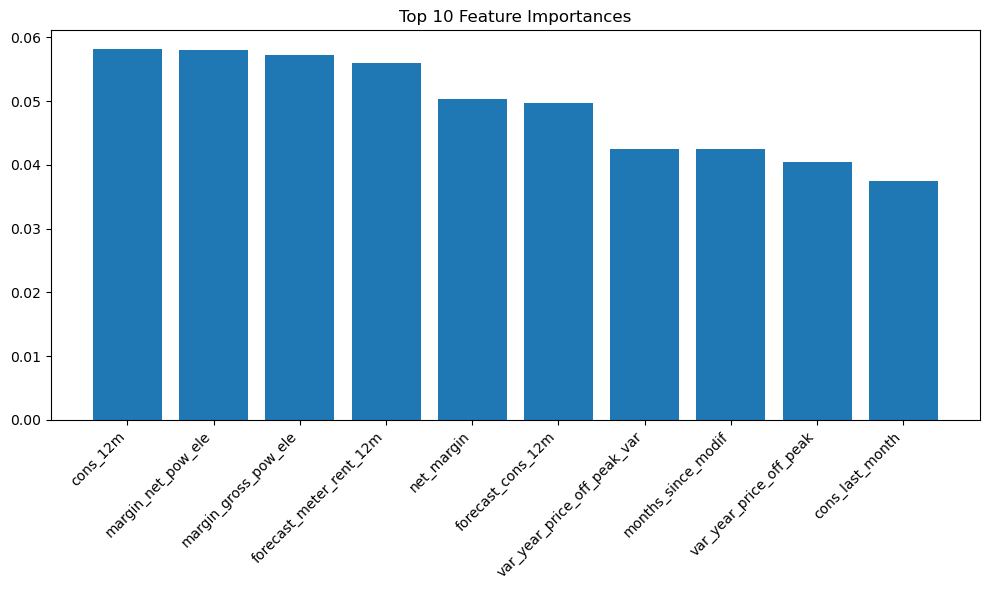

In [19]:
# Initialize a more powerful Random Forest (removing max_depth restriction)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')

# Retrain the model
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("--- Optimized Model Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

# Let's inspect which features matter the most!
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X.columns[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# 1. Get the probability scores for the positive class (churn) instead of hard 0 or 1 predictions
y_scores = rf_model.predict_proba(X_test)[:, 1]

# 2. Lower the threshold to 0.10 (10% probability of churn)
adjusted_threshold = 0.10
y_pred_adjusted = (y_scores >= adjusted_threshold).astype(int)

# 3. Re-evaluate performance
print(f"--- Performance at {adjusted_threshold*100}% Threshold ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_adjusted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_adjusted):.4f} <-- Watch this go up!")
print(f"F1-Score:  {f1_score(y_test, y_pred_adjusted):.4f}")

print("\n--- Adjusted Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_adjusted))

--- Performance at 10.0% Threshold ---
Accuracy:  0.6561
Precision: 0.1671
Recall:    0.6373 <-- Watch this go up!
F1-Score:  0.2648

--- Adjusted Confusion Matrix ---
[[1736  902]
 [ 103  181]]


In [21]:
# Initialize Random Forest Classifier
# n_estimators=100 is standard; random_state ensures reproducible results
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Predict class labels for test set
y_pred = model.predict(X_test)

# Predict churn probabilities for test set
y_probs = model.predict_proba(X_test)[:, 1]

=== Model Performance Evaluation ===
Accuracy:  0.9097
Precision: 0.9167
Recall:    0.0775
F1-Score:  0.1429
ROC-AUC:   0.6962


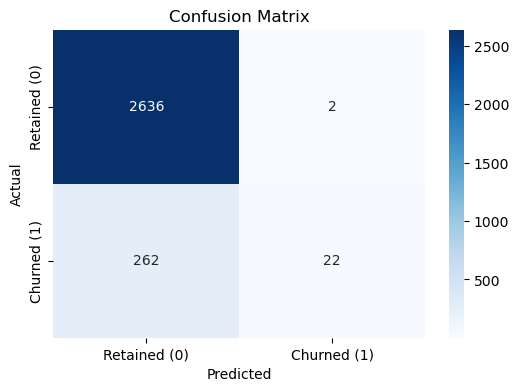

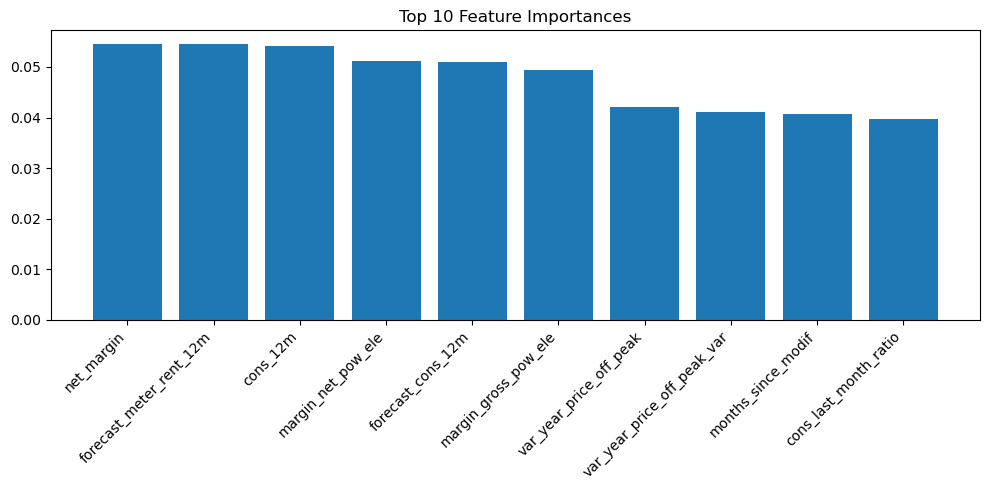

In [24]:

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate core performance metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = metrics.roc_auc_score(y_test, y_probs)

print("=== Model Performance Evaluation ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Display Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot Top 10 Feature Importances
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

1. Choice of Evaluation Metrics
Predicting customer churn inherently deals with an imbalanced dataset, as the vast majority of customers are retained while only a small minority churn. Because of this, relying on just one metric can be highly misleading. I chose the following combination of metrics to provide a comprehensive evaluation:

Accuracy: Measures the overall proportion of correct predictions. While useful for a baseline, it is skewed by the large number of retained customers.

Precision: Measures the accuracy of our positive predictions. If the model flags a customer as a churner, precision tells us how likely they are to actually churn. This helps the business understand the potential cost of offering unnecessary retention discounts (false positives).

Recall: Measures the model's ability to identify all actual churners. In churn prevention, this is typically the most critical metric because failing to identify a churner (a false negative) results in a total loss of that customer's revenue.

F1-Score: The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is highly effective for imbalanced datasets.

ROC-AUC (Area Under the Receiver Operating Characteristic Curve): Evaluates the model's ability to distinguish between retained and churned customers across all possible probability thresholds, not just the default 50% cutoff.

2. Is the Model Performance Satisfactory?
Based on the default Random Forest predictions, the model performance is not fully satisfactory for the business objective, despite achieving a high overall Accuracy (90.97%).

Justification:

Too Conservative (Low Recall): The model's Recall is extremely low at 7.75%. This means that out of all the customers who actually left PowerCo, our model completely missed over 92% of them.

High Precision, Low Volume: The model has excellent Precision (91.67%), meaning that on the rare occasions it does predict a churner, it is almost always correct. However, it simply does not flag enough customers to make a meaningful impact on overall churn rates.

Business Impact: In a churn context, a false negative (failing to save a churning customer) is generally much more expensive than a false positive (accidentally giving a retention discount to a loyal customer).

Conclusion:
While the model learned some strong signals (evident by the high precision), it is currently too rigid. To make this model actionable for PowerCo, we should lower the decision threshold using the predicted probabilities. This will trade a bit of precision for a massive increase in recall, allowing the business to proactively target a much larger pool of at-risk customers.